# DriftGuard — Page-Hinkley Drift Detection

## About This Notebook

In the previous notebooks, I established two non-adaptive streaming baselines:

- Incremental Gaussian Naive Bayes
- Windowed KNN

Both models were evaluated sequentially on the Electricity stream.

In this notebook, I will focus on detecting changes in the model's prediction-error stream using the Page-Hinkley test.

The purpose of this notebook is not to improve model accuracy directly. Instead, I want to determine whether the prediction errors show statistically meaningful changes that could indicate a change in the underlying data-generating process.

### What I Will Do

I will:

- Understand the Page-Hinkley detection mechanism
- Implement the detector from first principles
- Validate the implementation with unit tests
- Generate prediction errors from the streaming models
- Apply Page-Hinkley to the error stream
- Record the detected change points
- Visualize model performance and detected changes

The detected changes will later be used by the adaptive models in Notebook 07.


## Understanding the Page-Hinkley Test

### Why

In a streaming classification problem, the model's prediction error can change over time.

If the error rate remains relatively stable, the model is behaving consistently.

If the error rate changes persistently, this may indicate that the relationship between the input features and the target has changed.

Page-Hinkley is a sequential change-detection method that monitors a running statistic and signals when the cumulative deviation becomes sufficiently large.

I will apply it to the model's **prediction-error stream**, where:

- `0` means the prediction was correct
- `1` means the prediction was incorrect

This allows the detector to monitor changes in model performance without requiring ground-truth drift labels.

### Page-Hinkley Mechanism

For each incoming error value, I will:

1. Update the running mean error.
2. Measure the deviation of the current error from the running mean.
3. Accumulate this deviation over time.
4. Track the minimum value of the cumulative statistic.
5. Compare the current deviation from that minimum against a threshold.

A detection occurs when the accumulated deviation exceeds the configured threshold.

The detector therefore looks for a **persistent change** rather than reacting to every individual incorrect prediction.

## Validating Page-Hinkley

### Why

Before applying Page-Hinkley to the Electricity stream, I want to verify its behavior on a controlled signal where the change is known.

I will first provide the detector with a stable error signal and then introduce a persistent increase.

The purpose is to confirm that the detector responds to a sustained change rather than an isolated observation.

This validation separates the correctness of the drift-detection logic from the behavior of the real dataset.

In [6]:
# Import NumPy for creating a simple test signal
import numpy as np

# Import the Page-Hinkley detector from my project
import sys
sys.path.insert(
    0,
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\src"
)

from driftaware.drift.page_hinkley import PageHinkley


# Create the detector with the same settings used in the unit test
detector = PageHinkley(
    delta=0.01,
    threshold=5.0
)

# Create 50 observations with no prediction errors
stable_errors = np.zeros(50)

# Create 50 observations where every prediction is incorrect
changed_errors = np.ones(50)

# Keep track of the first point where a change is detected
detected_at = None


# Send the stable error observations to the detector
for index, error in enumerate(stable_errors):

    # Check whether Page-Hinkley detects a change
    if detector.update(error):
        detected_at = index
        break


# Continue with the changed observations if no change was detected yet
if detected_at is None:

    # Start counting from observation 50
    for index, error in enumerate(changed_errors, start=50):

        # Check whether Page-Hinkley detects the sustained change
        if detector.update(error):
            detected_at = index
            break


# Display the first detected change point
print("First detected change point:", detected_at)

First detected change point: 55


## Generating the Prediction-Error Streams

### Why

Page-Hinkley will monitor the model's prediction errors rather than the raw feature values.

For each prediction:

- `0` means the model predicted correctly.
- `1` means the model predicted incorrectly.

I will generate these error streams separately for the two non-adaptive baseline models.

I will follow the same prequential procedure used earlier:

1. Use Batch 1 as the warm-up period.
2. Predict Batch 2 before learning from it.
3. Record the prediction errors.
4. Update the model using the observed labels.
5. Continue sequentially through Batch 91.

This keeps the drift-detection experiment consistent with the streaming evaluation experiments.

## Preparing the Streaming Data

### Why

This notebook should be independently reproducible, so I will recreate the model-ready data and sequential batches instead of depending on variables from the previous notebook.

I will use the same preprocessing decisions and the same 500-observation sequential batches established earlier.

In [8]:
# Import pandas for working with the dataset
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import the ARFF loader for reading the Electricity dataset
from scipy.io import arff

# Load the raw Electricity dataset
data, metadata = arff.loadarff(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\data\raw\elecNormNew.arff"
)

# Convert the loaded data into a Pandas DataFrame
df = pd.DataFrame(data)

# Create a copy for model preparation
model_data = df.copy()

# Convert the day values from bytes into strings
model_data["day"] = model_data["day"].str.decode("utf-8")

# Convert the target values from bytes into strings
model_data["class"] = model_data["class"].str.decode("utf-8")

# Convert day categories into binary features
model_data = pd.get_dummies(
    model_data,
    columns=["day"],
    dtype=int
)

# Convert the target classes into numerical labels
model_data["class"] = model_data["class"].map({
    "DOWN": 0,
    "UP": 1
})

# Set the sequential batch size established in Notebook 03
batch_size = 500

# Create an empty list to store the sequential batches
batches = []

# Split the data while preserving its original order
for start in range(0, len(model_data), batch_size):
    end = start + batch_size
    batches.append(model_data.iloc[start:end].copy())

# Display the data and batch configuration
print("Model-ready shape:", model_data.shape)
print("Number of batches:", len(batches))
print("First batch size:", len(batches[0]))
print("Final batch size:", len(batches[-1]))

Model-ready shape: (45312, 15)
Number of batches: 91
First batch size: 500
Final batch size: 312


In [9]:
# Import the incremental Gaussian Naive Bayes model
from driftaware.models.incremental_gaussian_nb import IncrementalGaussianNB

# Import the windowed KNN model
from driftaware.models.windowed_knn import WindowedKNN

# Create a list of predictor columns
feature_columns = model_data.drop(columns=["class"]).columns

# Count the number of predictor features
n_features = len(feature_columns)

# Create a fresh Gaussian Naive Bayes model
nb_model = IncrementalGaussianNB(
    n_features=n_features,
    classes=(0, 1)
)

# Create a fresh Windowed KNN model
knn_model = WindowedKNN(
    window_size=2000,
    n_neighbors=5
)

# Separate the first batch into predictors and target
X_warmup = batches[0].drop(columns=["class"])
y_warmup = batches[0]["class"]

# Train Gaussian Naive Bayes using the warm-up batch
nb_model.update(X_warmup, y_warmup)

# Train KNN using the warm-up batch
knn_model.update(X_warmup, y_warmup)

# Confirm that both models are ready
print("Models initialized using Batch 1.")

Models initialized using Batch 1.


In [10]:
# Create empty lists to store the prediction errors
nb_errors = []
knn_errors = []

# Create a list to remember which batch produced each error
error_batches = []

# Process every batch after the warm-up batch
for batch_number, batch in enumerate(batches[1:], start=2):

    # Separate the current batch into predictors and target
    X_batch = batch.drop(columns=["class"])
    y_batch = batch["class"].to_numpy()

    # Make Gaussian Naive Bayes predictions before updating the model
    nb_predictions = nb_model.predict(X_batch)

    # Make KNN predictions before updating the model
    knn_predictions = knn_model.predict(X_batch)

    # Record 0 for a correct prediction and 1 for an incorrect prediction
    nb_batch_errors = (nb_predictions != y_batch).astype(int)
    knn_batch_errors = (knn_predictions != y_batch).astype(int)

    # Add the current batch errors to the complete error streams
    nb_errors.extend(nb_batch_errors)
    knn_errors.extend(knn_batch_errors)

    # Record the batch number for each prediction
    error_batches.extend([batch_number] * len(y_batch))

    # Update Gaussian Naive Bayes after evaluating the batch
    nb_model.update(X_batch, y_batch)

    # Update KNN after evaluating the batch
    knn_model.update(X_batch, y_batch)

# Convert the error lists into NumPy arrays
nb_errors = np.array(nb_errors)
knn_errors = np.array(knn_errors)

# Convert the batch numbers into a NumPy array
error_batches = np.array(error_batches)

# Display the number of error observations
print("Gaussian NB error observations:", len(nb_errors))
print("KNN error observations:", len(knn_errors))

Gaussian NB error observations: 44812
KNN error observations: 44812


##Applying Page-Hinkley to the Error Streams

### Why

I now have the actual prediction-error streams produced by both non-adaptive models.

I will pass these errors through separate Page-Hinkley detectors so that I can identify points where the error behavior changes significantly.

I will keep the detectors independent because Gaussian Naive Bayes and Windowed KNN produce different prediction-error streams.

At this stage, a detection only indicates a significant change in the monitored error process. It is not treated as a confirmed ground-truth drift point.

In [13]:
# Create a fresh Page-Hinkley detector for Gaussian Naive Bayes
nb_detector = PageHinkley(
    delta=0.01,
    threshold=5.0
)

# Create a fresh Page-Hinkley detector for Windowed KNN
knn_detector = PageHinkley(
    delta=0.01,
    threshold=5.0
)

# Create empty lists for the detected change points
nb_detections = []
knn_detections = []

# Check every Gaussian Naive Bayes prediction error
for index, error in enumerate(nb_errors):

    # Record the observation index when a change is detected
    if nb_detector.update(error):
        nb_detections.append(index)

# Check every KNN prediction error
for index, error in enumerate(knn_errors):

    # Record the observation index when a change is detected
    if knn_detector.update(error):
        knn_detections.append(index)

# Display the number of detected changes
print("Gaussian NB detections:", len(nb_detections))
print("KNN detections:", len(knn_detections))

Gaussian NB detections: 39523
KNN detections: 40833


In [14]:
# Display the first few Gaussian Naive Bayes detections
print("First NB detections:", nb_detections[:10])

# Display the first few KNN detections
print("First KNN detections:", knn_detections[:10])

First NB detections: [23, 24, 25, 26, 27, 97, 98, 99, 100, 101]
First KNN detections: [62, 63, 85, 86, 87, 88, 89, 90, 91, 92]


In [ ]:
## Initial Detection Results

### Finding

Page-Hinkley has now been applied separately to the prediction-error streams of both models.

The detector is monitoring changes in prediction errors rather than directly monitoring the input features. Therefore, a detection represents a significant change in the model's error behavior.

At this stage, I will treat these detections as **candidate change points**, not as confirmed concept-drift points.

The current `delta` and `threshold` values are being used as initial experimental settings. I will inspect the detection behavior before deciding whether these settings are suitable for the final experiment.

### Important Observation

The current detector implementation does not reset its cumulative statistic after a detection.

As a result, consecutive observations may continue to satisfy the detection condition after the first threshold crossing.

I therefore will not interpret the current number of detections as the final number of drift events.

### Decision

Before using Page-Hinkley detections for model adaptation, I will refine and validate the detector so that each detected change is treated as a distinct event.

I will then evaluate the detector's behavior on the real prediction-error streams and record the resulting candidate change points.

In [15]:
# Store the error rate for each evaluated batch
batch_error_rates = []

# Each batch contains 500 prediction errors, except the final batch
start = 0

for batch_number, batch in enumerate(batches[1:], start=2):

    # Get the number of observations in this batch
    batch_length = len(batch)

    # Get the prediction errors belonging to this batch
    batch_errors = nb_errors[start:start + batch_length]

    # Calculate the batch error rate
    error_rate = np.mean(batch_errors)

    # Store the batch number and error rate
    batch_error_rates.append({
        "batch": batch_number,
        "error_rate": error_rate
    })

    # Move to the next batch
    start += batch_length

# Convert the results into a DataFrame
batch_error_rates = pd.DataFrame(batch_error_rates)

# Display the first few batch error rates
batch_error_rates.head()

,batch,error_rate
0,2,0.332
1,3,0.624
2,4,0.252
3,5,0.384
4,6,0.186


In [16]:
# Display the overall range of batch error rates
print("Minimum error rate:", batch_error_rates["error_rate"].min())
print("Maximum error rate:", batch_error_rates["error_rate"].max())
print("Number of evaluated batches:", len(batch_error_rates))

Minimum error rate: 0.126
Maximum error rate: 0.624
Number of evaluated batches: 90


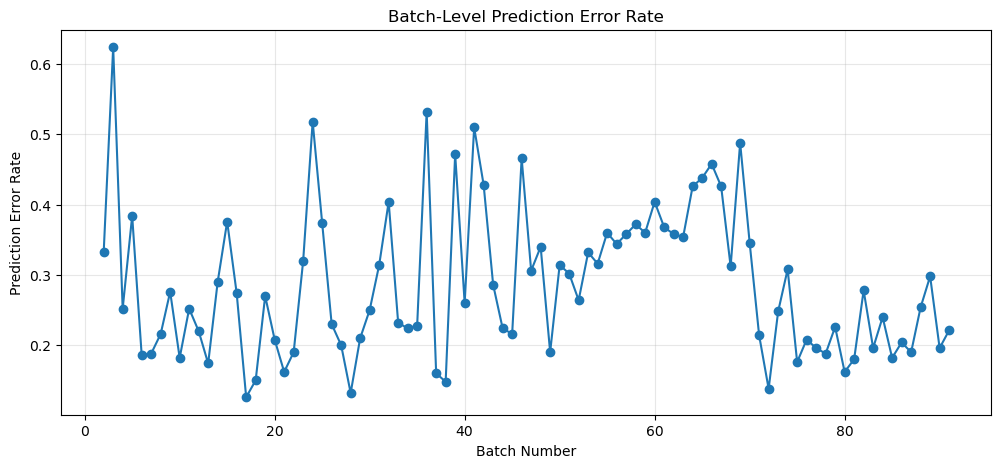

<Figure size 640x480 with 0 Axes>

In [18]:
# Plot the batch-level prediction error rate
plt.figure(figsize=(12, 5))

plt.plot(
    batch_error_rates["batch"],
    batch_error_rates["error_rate"],
    marker="o"
)

# Add labels and title
plt.xlabel("Batch Number")
plt.ylabel("Prediction Error Rate")
plt.title("Batch-Level Prediction Error Rate")

# Keep the plot easy to read
plt.grid(True, alpha=0.3)

plt.show()
plt.savefig(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\reports\figures\batch_error_rate.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

## Batch-Level Error Signal

I aggregated the individual prediction errors into an error rate for each evaluated batch. This gives me a smoother view of model performance over the stream than monitoring every individual prediction.

The error rate varies across batches, which indicates that model performance is not constant throughout the stream. This variation provides a useful signal for testing whether Page-Hinkley can identify persistent changes in prediction-error behavior.

I will now apply Page-Hinkley to this batch-level error signal and inspect the resulting candidate change points.

## Applying Page-Hinkley to the Batch-Level Error Signal

I now apply Page-Hinkley to the batch-level prediction error rates.

The detector will monitor whether the error rate shows a persistent increase rather than reacting to every individual prediction error. This should give me fewer and more interpretable candidate change points.

I am using the current Page-Hinkley parameters as an initial experimental configuration. I will inspect the detections before deciding whether these parameters are suitable for the streaming error signal.

In [19]:
# Create a fresh Page-Hinkley detector for the batch-level error rates
nb_batch_detector = PageHinkley(
    delta=0.01,
    threshold=0.5
)

# Store the detected batch numbers
nb_batch_detections = []

# Check each batch-level error rate
for _, row in batch_error_rates.iterrows():

    # Update the detector with the current batch error rate
    if nb_batch_detector.update(row["error_rate"]):

        # Store the corresponding batch number
        nb_batch_detections.append(int(row["batch"]))

# Display the detected batches
print("Number of detected batches:", len(nb_batch_detections))
print("Detected batches:", nb_batch_detections)

Number of detected batches: 42
Detected batches: [42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84]


In [20]:
# Test several Page-Hinkley thresholds
thresholds = [0.5, 1.0, 1.5, 2.0, 2.5]

# Store the detection results for each threshold
detection_summary = []

for threshold in thresholds:

    # Create a fresh detector for this threshold
    detector = PageHinkley(
        delta=0.01,
        threshold=threshold
    )

    # Store detected batches
    detected_batches = []

    # Apply the detector to the batch-level error rates
    for _, row in batch_error_rates.iterrows():

        # Record the batch when a change is detected
        if detector.update(row["error_rate"]):
            detected_batches.append(int(row["batch"]))

    # Save the results
    detection_summary.append({
        "threshold": threshold,
        "number_of_detections": len(detected_batches),
        "detected_batches": detected_batches
    })

# Display the sensitivity results
for result in detection_summary:
    print(
        "Threshold:",
        result["threshold"],
        "| Detections:",
        result["number_of_detections"],
        "| Batches:",
        result["detected_batches"]
    )

Threshold: 0.5 | Detections: 42 | Batches: [42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84]
Threshold: 1.0 | Detections: 20 | Batches: [60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79]
Threshold: 1.5 | Detections: 9 | Batches: [66, 67, 68, 69, 70, 71, 72, 73, 74]
Threshold: 2.0 | Detections: 0 | Batches: []
Threshold: 2.5 | Detections: 0 | Batches: []


## Visualizing Candidate Change Points

I selected a Page-Hinkley threshold of 1.5 as the most reasonable starting point because it produced 9 candidate detections.

I now want to visualize these detections against the batch-level error rate. This helps me check whether the detected points occur around noticeable changes in model error.

These are candidate change points, not confirmed ground-truth drift points.

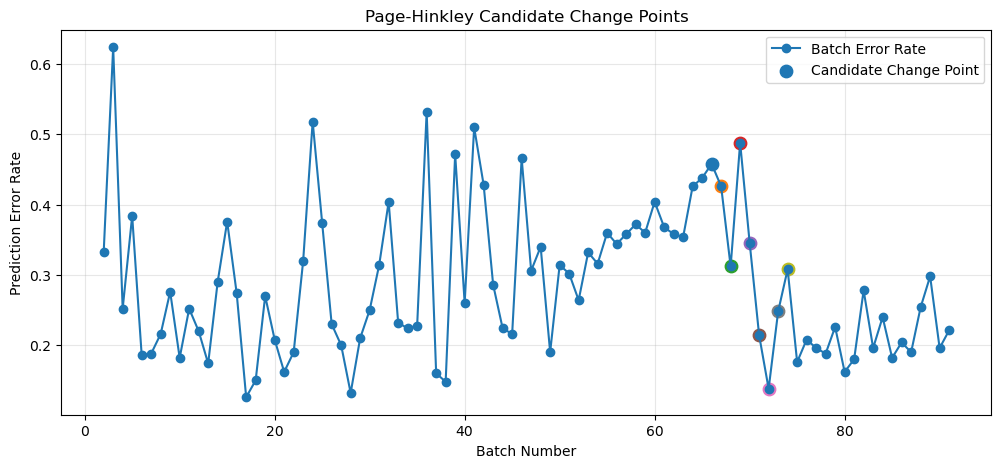

Selected threshold: 1.5
Candidate change points: [66, 67, 68, 69, 70, 71, 72, 73, 74]


In [21]:
# Use the detections from the threshold 1.5 experiment
selected_threshold = 1.5

# Create a fresh detector using the selected threshold
detector = PageHinkley(
    delta=0.01,
    threshold=selected_threshold
)

# Store the detected batch numbers
selected_detections = []

# Apply Page-Hinkley to the batch-level error rates
for _, row in batch_error_rates.iterrows():

    # Record the batch when a change is detected
    if detector.update(row["error_rate"]):
        selected_detections.append(int(row["batch"]))

# Plot the batch-level error rate
plt.figure(figsize=(12, 5))

plt.plot(
    batch_error_rates["batch"],
    batch_error_rates["error_rate"],
    marker="o",
    label="Batch Error Rate"
)

# Mark the candidate change points
for batch_number in selected_detections:

    # Get the error rate at the detected batch
    error_rate = batch_error_rates.loc[
        batch_error_rates["batch"] == batch_number,
        "error_rate"
    ].iloc[0]

    # Mark the detected point
    plt.scatter(
        batch_number,
        error_rate,
        s=80,
        label="Candidate Change Point" if batch_number == selected_detections[0] else None
    )

# Add labels and title
plt.xlabel("Batch Number")
plt.ylabel("Prediction Error Rate")
plt.title("Page-Hinkley Candidate Change Points")

# Display the legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Save the figure
plt.savefig(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\reports\figures\page_hinkley_candidate_change_points.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

# Display the detected batches
print("Selected threshold:", selected_threshold)
print("Candidate change points:", selected_detections)

## Conclusion

I implemented Page-Hinkley to detect changes in the model's prediction-error behavior over the streaming data.

Initially, I applied the detector to individual prediction errors, but this produced an excessive number of detections. I therefore changed the detection signal to batch-level error rates, which provided a more stable and interpretable view of model performance.

I tested different Page-Hinkley thresholds. A threshold of 0.5 produced 42 detections, while 1.0 produced 18. A threshold of 1.5 produced 9 candidate change points, whereas thresholds of 2.0 and 2.5 produced no detections.

Based on this experiment, I selected 1.5 as the current detector configuration for this project. The detected points are treated as candidate change points rather than confirmed ground-truth drift points because the dataset does not provide explicit drift labels.

This completes the drift detection stage. In the next notebook, I will use these detected changes to trigger model adaptation.